## QTCAD Simulation of a Single Quantum Dot in FD-SOI Technology
### Generation of Synthetic Dataset for Quantum Machine Learning

**Author:** Ana Elisa Franco Flores  
**Date:** May 1st, 2026  
**Course:** QOSF Mentorship Program  
**Mentor:** Daniel Sierra-Sosa  

#### Overview

In this notebook I simulated a single quantum dot in a 22nm FD-SOI (Fully Depleted Silicon-On-Insulator) structure using QTCAD. The simulation solves the Poisson and Schrödinger equations to compute the ground state energy of a confined electron as a function of the plunger gate voltage.

#### Objective

Generate a synthetic dataset (plunger_voltage_V, ground_energy_eV, clase) to be used for training classical and quantum machine learning classifiers (SVM with RBF kernel and quantum kernel with ZFeatureMap).

#### Glossary of Key Terms

With the purpose of introducing the reader to the key concepts used throughout this notebook, we provide the following glossary. These terms span quantum dot physics, semiconductor device architecture, numerical simulation, and quantum machine learning. A solid understanding of this terminology will facilitate the interpretation of the simulation workflow and the resulting dataset.

**Physics & Device Architecture**

- **QTCAD**: Quantum Technology Computer-Aided Design. A software package that solves Poisson and Schrödinger equations for quantum devices.
- **Quantum Dot**: A nanometer-scale region in a semiconductor where electrons can be trapped. Acts as an "artificial atom".
- **FD-SOI**: Fully Depleted Silicon-On-Insulator. A chip technology where a thin silicon layer sits on top of an insulator, providing excellent electrostatic control.
- **Plunger Gate**: The gate electrode that creates the potential well trapping the electron. In this project the single gate the range is 
(0.4-0.9 V). 
- **Barrier Gate**: Side gates that act as walls, preventing the electron from escaping the quantum dot.
- **Back Gate**: A gate beneath the silicon channel that helps push electrons toward the plunger gate(s).
- **Lever Arm (α)**: A linear coefficient that quantifies how effectively a gate voltage shifts the energy levels of a quantum dot. Defined as α = ΔE/(q·ΔV), where q is the electron charge. Enables fast energy shifts without re-solving the Schrödinger equation. Key concept for scaling to multiple variables.
- **Reference Bias**: The specific gate voltage configuration where the full Poisson and Schrödinger equations are solved. All other points use lever arms to shift energies relative to this reference.

**Quantum States & Energy Levels**

- **Ground State Energy**: The lowest allowed energy level for an electron in the quantum dot. This is our primary output.
- **Excited States**: Higher energy levels beyond the ground state (1st, 2nd, etc.). Captured but not the primary focus.
- **Fermi Level**: A reference energy. If the ground state energy is above it → dot is empty. If below → dot is occupied.
- **Empty (Class 0)**: Regime where no electron is trapped in the quantum dot.
- **Occupied (Class 1)**: Regime where an electron is trapped in the quantum dot (one-electron regime, suitable for spin qubits).
- **Transition Region**: The unstable voltage range (0.62 - 0.71 V for SQD) where the electron is entering or leaving the dot. Excluded from our dataset.

**Numerical Methods**

- **Poisson Equation**: Solves for the electrostatic potential distribution inside the device given applied gate voltages.
- **Schrödinger Equation**: Solves for the allowed energy levels of an electron confined in the potential well.
- **Mesh**: The 3D discretization of the device geometry into thousands of tetrahedral elements. QTCAD solves equations on this mesh.
- **Synthetic Dataset**: Computer-generated data that mimics experimental measurements. Used here to train machine learning models.
- **Lever Arm Approximation**: A linear approximation that shifts energy levels based on gate voltage changes without re-solving the Schrödinger equation. Valid for small voltage variations around a reference bias.
- **Energy Shift**: The linear correction applied to reference energies using lever arms: ΔE = -α·q·ΔV.

**Classical Machine Learning**

- **SVM (Support Vector Machine)**: A supervised learning algorithm that finds the optimal hyperplane separating classes. Effective in high-dimensional spaces.
- **RBF Kernel**: Radial Basis Function kernel. Measures similarity between data points in infinite-dimensional space. Used in SVM for non-linear classification.
- **Classification**: Supervised learning task where the output is a discrete label (e.g., empty or occupied).
- **Accuracy**: Metric measuring the fraction of correct predictions.
- **Training Set**: Subset of data used to train the model (70% in our split).
- **Test Set**: Subset of data used to evaluate the model (30% in our split).
- **Confusion Matrix**: A table showing correct and incorrect predictions per class.

**Quantum Machine Learning**

- **Quantum Kernel**: A similarity measure computed via quantum circuits. Maps classical data to quantum Hilbert space.
- **ZFeatureMap**: A quantum feature map that encodes classical data using only RZ rotations. No entanglement. Suitable for 1-2 variables. U
 **ZZFeatureMap**: A quantum feature map that encodes classical data using RZ and ZZ entanglement gates. Introduces entanglement between qubits, making it suitable for problems with 3+ variables. Uses reps (repetitions) and entanglement (e.g., 'linear', 'full') parameters. 
- **FidelityQuantumKernel**: Qiskit class that computes kernel matrices using quantum circuit fidelity.
- **Qubit**: Basic unit of quantum information. In our feature maps, one qubit per variable.
- **Entanglement**: Quantum correlation between qubits. Enabled in ZZFeatureMap but not in ZFeatureMap.
- **Feature Map**: A quantum circuit that encodes classical data into quantum states.
- **Hilbert Space**: The high-dimensional complex vector space where quantum states live. Quantum kernels leverage its exponential size.

#### Key Features

- **Device:** FD-SOI quantum dot
- **Materials:** Silicon (Si), Silicon Dioxide (SiO₂), Hafnium Oxide (HfO₂)
- **Gates:** Plunger (variable), Barrier 1 & 2 (fixed), Back gate (fixed)
- **Temperature:** 0.1 K (cryogenic)
- **Simulation:** Non-linear Poisson + Schrödinger with adaptive mesh refinement

#### Output

- CSV file: `Quantum_Dot_dataset.csv` with columns:
- `plunger_voltage_V`: Applied voltage (V)
- `ground_energy_eV`: Ground state energy (eV)
- `energy_1st_excited_eV`: First excited state energy (eV)
- `energy_2nd_excited_eV`: Second excited state energy (eV)
- `class`: Classification (0 = empty, 1 = occupied)

#### Dependencies

- QTCAD (license required)
- Python 3.13+
- NumPy, Matplotlib, pandas
- scikit-learn (SVM, train_test_split, metrics)
- SciPy (linregress, Latin Hypercube Sampling)
- Qiskit (ZFeatureMap, FidelityQuantumKernel)
- qiskit-machine-learning

## The Problem: Why This Project Matters

A quantum computer requires thousands (or millions) of qubits to solve problems that are impossible for classical computers today. Among the leading qubit technologies, **silicon spin qubits** stand out because they can be fabricated using existing industrial CMOS processes, the most advanced and scalable semiconductor manufacturing platform in existence.

However, there is a critical bottleneck: **qubit calibration**.

For each quantum dot that will host a spin qubit, scientists must:
1. Find the correct gate voltages that trap exactly **one electron**
2. Verify that the electron is stable (not tunneling away)
3. Ensure the dot operates in a regime where the spin can be initialized, manipulated, and read out.

Currently, this calibration is done **manually** through trial and error. It takes **weeks per qubit** and does not scale to the thousands of qubits needed for a useful quantum computer.

#### The Opportunity

Machine learning offers a path toward **faster, more systematic calibration**. The idea is simple: instead of searching the voltage space blindly, we can train a model to predict the quantum dot state directly from gate voltages.

**What we actually built:** A complete pipeline that goes from device simulation (QTCAD) to dataset generation to classical and quantum machine learning classifiers.

**What we demonstrated:** 
- 100% accuracy on binary classification (empty vs. occupied)
- Quantum kernels (ZFeatureMap) achieve the same performance as classical RBF kernels on this task
- A modular pipeline ready to scale to more complex scenarios

**What this enables right now:**
- A reproducible workflow for generating synthetic quantum dot datasets
- A baseline for comparing classical vs. quantum kernels
- A foundation for active learning (choosing which simulations are most informative)

**What this prepares us for:**

- **Scaling to Double Quantum Dots (DQD)**: Unlike single dots, DQD has non-linear charge stability diagrams, multiple electron states (0,0), (1,0), (0,1), (1,1), and no simple voltage threshold. This is where ML and QML become truly necessary.
- **Entanglement-aware quantum kernels**: Single dot required only ZFeatureMap (no entanglement). DQD naturally calls for ZZFeatureMap with entanglement between qubits, better aligning with the physics of coupled dots.
- **Many-body physics**: While single dot needs only the Schrödinger equation, DQD requires a many-body solver to capture Coulomb interactions between electrons. ML can help approximate these expensive calculations.
- **Active learning for expensive simulations**: DQD many-body simulations are computationally costly. Active learning can reduce the number of required simulations by focusing on the most informative points in the voltage space.
- **Scalable qubit calibration**: The ultimate goal is to automate the search for optimal gate voltages across thousands of quantum dots on a chip. This pipeline is the first step toward that vision.

#### My Contribution: A Scalable Pipeline from 1 to N Variables

In this project, I establish a **proof-of-concept pipeline** that generates synthetic datasets from QTCAD simulations and trains both classical and quantum machine learning classifiers.

**Key finding from this work:** Both the classical SVM (RBF kernel) and the quantum SVM (ZFeatureMap) achieved **100% accuracy** on the test set. This confirms that the pipeline works and provides a solid baseline for future scaling.

#### Current Implementation (1 Variable)

This notebook focuses on the simplest possible scenario: **a single plunger gate voltage** as the only input variable. The dataset maps applied gate voltage to the ground state energy and classifies each point as:

- **Empty (Class 0)**: No electron trapped → not usable as a qubit
- **Occupied (Class 1)**: One electron trapped → ideal for a spin qubit

The transition region (unstable) is excluded because it is not suitable for qubit operation.

| Input | Output |
|-------|--------|
| plunger_voltage_V (0.40 - 0.90 V) | `class` (0 = empty, 1 = occupied) |

#### Why Start with 1 Variable?

| Reason | Explanation |
|--------|-------------|
| **Feasibility test** | Verify that QTCAD + ML pipeline works end-to-end |
| **Physics validation** | Confirm that energy decreases monotonically with voltage |
| **Baseline establishment** | Get 100% accuracy as a reference for more complex cases |
| **Debugging simplicity** | Easier to identify issues with one variable |
| **Compute time** | ~1 hour for 30 points — manageable for iteration |

#### Personal Learning Journey

I started from zero in both fields: QTCAD and quantum machine learning. To execute this project, I needed:

- A **5-week introductory course on QTCAD** to understand device simulation (mesh, Poisson, Schrödinger, gates, materials)
- **Active learning** (in the human sense) of both QML and semiconductor physics, reading documentation, testing code, debugging, and gradually building understanding

Neither the simulations nor the quantum kernels came naturally at first. Each component required iterative effort: understanding why Poisson fails to converge, why the lever arm approximation gives nonsense, why the quantum kernel returns zeros. The final notebook represents not just code, but weeks of trial and error, questions asked, and concepts slowly falling into place.

This 1-variable project is the result of that learning process, a working proof of concept that I now understand well enough to explain and extend.

#### The Long-Term Vision: Double Quantum Dot (DQD)

A real quantum processor requires **coupled qubits**. The next logical step beyond a single quantum dot is a **Double Quantum Dot (DQD)** , where two dots are coupled by a tunable barrier. This enables:

- Two-electron states (singlet, triplet)
- Quantum gates via exchange interaction
- Scalable qubit arrays

**Why DQD is the natural next step:**

| Aspect | Single Dot (Current) | Double Dot (Future) |
|--------|---------------------|---------------------|
| **Control knobs** | 1-4 gates | 5-6 gates (PL, PR, B1, B2, B3, BG) |
| **Electron states** | 0 or 1 electron | (0,0), (1,0), (0,1), (1,1) |
| **Output classes** | 2 (empty/occupied) | 4+ charge states + spin states |
| **Qubit type** | Single spin qubit | Singlet-triplet qubit |
| **Physical complexity** | Single particle | Many-body (Coulomb interaction) |

**What changes when scaling to DQD:**

| Aspect | Single Dot | Double Quantum Dot |
|--------|-----------|---------------------|
| **Solver** | Schrödinger | Many-body solver |
| **Key physics** | Confinement | Tunneling + Coulomb repulsion |
| **Feature map** | ZFeatureMap | ZZFeatureMap (entanglement needed) |
| **ML relevance** | Demonstrative | **High** (non-linear boundaries) |

**The Roadmap:**

| Phase | System | Variables | Status |
|-------|--------|----------|--------|
| **Phase 1** | Single quantum dot | 1 (plunger) | **COMPLETE** |
| **Phase 2** | Double quantum dot (DQD) | 2 (PL, PR) | **NEXT** |
| **Phase 3** | Double quantum dot (DQD) | 4+ (PL, PR, B_center, BG) | Future |

**Why DQD matters for QML:**

In DQD, the relationship between gate voltages and charge states is highly non-linear due to:
- Tunneling between dots
- Coulomb repulsion between electrons
- Singlet-triplet transitions

These non-linearities make ML and QML particularly valuable, there is no simple threshold rule like in single dot classification.

#### Pipeline Architecture (Designed for Scalability)

The pipeline is built to scale:
- The simulation function accepts any number of gate voltages
- The dataset generation can use grid search or active learning
- The ML models (classical and quantum) handle higher dimensions naturally
- Transfer learning can bridge simulation → experiment

#### Key Takeaway

**Both classical (RBF) and quantum (ZFeatureMap) kernels achieved 100% accuracy on the 1-variable problem.** This confirms the pipeline works. The next step is scaling to **Double Quantum Dots (DQD)** , starting with 2 variables (PL, PR) to generate the honeycomb charge stability diagram, then progressing to 4+ variables (PL, PR, B_center, BG). This is where manual calibration becomes impractical and machine learning becomes truly essential. This notebook provides the foundation for that journey.
---

## A brief introduction about the QTCAD Software: What QTCAD solves: Poisson and Schrödinger equations

QTCAD simulates quantum dots by solving two fundamental equations. Understanding what each one does helps interpret the results.

### Poisson equation

This equation calculates how the voltage distributes inside the device when we apply voltages to the gates. Think of it as mapping the electric field across the chip. The result is a potential profile φ(r) that tells the electron where it is energetically favorable to be.

**Equation:**

∇ · (ε(r) ∇φ(r)) = -ρ(r)

where:
- φ(r) is the electrostatic potential at position r (output)
- ε(r) is the dielectric constant of the material
- ρ(r) is the charge density (electrons + dopants)

In simple terms: **Poisson tells the electrons where to go.**

### Schrödinger equation

This equation calculates the allowed energy levels of an electron trapped in the potential well created by the gates. Only certain discrete energies are possible (eigenenergies).

**Equation:**

[- (ħ²/2m*) ∇² + V(r)] ψ(r) = E ψ(r)

where:
- ψ(r) is the electron wavefunction (output)
- V(r) is the potential energy from Poisson + gate voltages
- E is the allowed energy eigenvalue (output)
- m* is the effective electron mass in silicon

In simple terms: **Schrödinger tells the electron what energies it can have.**

#### How QTCAD builds the device

Before solving the equations, QTCAD needs a 3D representation of the device. The workflow is:

1. **Mask design (KLayout)**: We draw the gate patterns using KLayout, a tool for integrated circuit layout. This defines where each gate (plunger, barriers, back gate) is placed.

2. **Mesh**: The device geometry is divided into thousands of small tetrahedra (3D triangles). This is called the mesh. QTCAD solves the equations on each tetrahedron, so the mesh quality affects accuracy and simulation time.

3. **SubMesh**: Sometimes we only care about a specific region (for example, the area where the quantum dot forms). A SubMesh is a portion of the full mesh, extracted to save computational time.

4. **Device**: This is the main object that contains the full mesh, material properties (silicon, oxides), doping concentrations, and boundary conditions (gate voltages).

5. **SubDevice**: Similar to SubMesh, a SubDevice is a smaller version of the Device. It contains only the region of interest (the quantum dot area). We use it for the Schrödinger solver because solving the full device would be too slow.

In summary:
- **Mask** → 
- **Mesh** → divides the device into small pieces
- **SubMesh** → extracts a region of interest
- **Device** → holds everything (mesh + materials + voltages)
- **SubDevice** → holds only the quantum dot region for faster quantum calculations

#### How Poisson and Schrödinger work together

1. We apply gate voltages (what we control).
2. Poisson solves for the potential landscape (where the electron wants to go).
3. That potential becomes the input for Schrödinger.
4. Schrödinger solves for the energy levels (what energies the electron can have).
5. The lowest energy (ground state) tells us if the dot is empty or occupied.

---

### Here we GO!

---

#### 1. Setup and imports

First, we load all the libraries we need. 

- numpy, pandas, and matplotlib are standard Python libraries for numerical calculations, data handling, and plotting.
- The qtcad imports bring the tools for device simulation: materials, mesh handling, and the Poisson and Schrödinger solvers.

If you are running this notebook for the first time, make sure you have QTCAD installed and the license activated. The mesh files (`sqdfdsoi.msh` and `sqdfdsoi.xao`) should be in a folder named `meshes` in the same directory as this notebook.

In [104]:
## 1. Library Imports and Configuration
## Imports: QTCAD, NumPy, Matplotlib, Pandas

from pathlib import Path
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from qtcad.device import constants as ct
from qtcad.device import materials as mt
from qtcad.device import analysis as an
from qtcad.device import io
from qtcad.device.mesh3d import Mesh, SubMesh
from qtcad.device import Device, SubDevice
from qtcad.device.poisson import Solver as PoissonSolver
from qtcad.device.poisson import SolverParams as PoissonSolverParams
from qtcad.device.schrodinger import Solver as SchrodingerSolver
from qtcad.device.schrodinger import SolverParams as SchrodingerSolverParams


---

### 2. Device parameters (FD-SOI)

Here we define all the fixed parameters of our quantum dot device: gate voltages, geometry buffers, temperature, and solver tolerances. These values come from the FD-SOI technology and remain constant across simulations. **Only the plunger gate voltage will change later.**

In [77]:
# Fixed gate voltages
v_barrier_1 = 0.55   # left barrier
v_barrier_2= 0.55    # right barrier
v_back_gate = -0.47  # back gate

# Dot region buffers (meters)
buffer_bottom = 10e-9
buffer_top = 2e-9
buffer_leads = 15e-9
buffer_spacers = 5e-9

# Temperature in Kelvin
temperature = 0.1

# Solver precision
poisson_tol = 1e-3
schrodinger_tol = 1e-6

# Mesh size control
min_nodes = 50000
max_nodes = 100000
max_iter = 200

### Device structure

The image below shows the 3D geometry of the FD-SOI quantum dot device as rendered by QTCAD. It was generated by running `dvc.show()` after loading the mesh and defining the device regions.

The visualization displays:
- **Silicon channel** (central region where the quantum dot forms)
- **Gate electrodes** (plunger, barrier gates, back gate)
- **Source and drain contacts** (highly n-doped silicon)
- **Oxide layers** (SiO₂ box and spacers, HfO₂ gate oxide)

This structure corresponds to the mesh file `sqdfdsoi.msh` and the geometry file `sqdfdsoi.xao` located in the `meshes/` folder. The device parameters (materials, doping, gate voltages) are defined in the simulation code before calling dvc.show().

**About this device:** The mesh and materials were provided as part of the **QTCAD® EDU - Semicon Program** . It is a simplified FD-SOI quantum dot structure designed for teaching and prototyping. While it captures the essential physics; Poisson and Schrödinger equations, gate control, single-electron confinement. It is not intended for direct device fabrication. 

The actual simulation function that loads this mesh, assigns materials, applies voltages, and solves the Poisson and Schrödinger equations is described in detail in **Section 4 (Quantum dot simulation function)** below.

*Note: The visualization is a snapshot of the device at the reference bias (plunger = 0.65 V, barriers = 0.55 V, back gate = -0.47 V).*

<center>
  <img src="device_structure.png" width="400">
</center>

---
### 3. Quantum dot simulation function

We start with the simulation function because it is the core of our workflow. This function takes a plunger gate voltage as input, solves the Poisson and Schrödinger equations for the FD-SOI device, and returns the energy levels of the confined electron.

#### Why we need this function

In order to generate a dataset, we need to run the same simulation many times with different plunger voltages. Writing a function allows us to do this without repeating code. Each call to the function performs a complete simulation: from loading the mesh to solving the quantum mechanics.

#### What this function does step by step

1. **Loads the mesh** from the `.msh` file. This mesh was created earlier using KLayout and represents the 3D geometry of the FD-SOI device.

2. **Creates the device** and assigns materials (silicon for the channel, oxides for insulation, doped silicon for source and drain).

3. **Applies gate voltages**: the barrier and back gates stay fixed, while the plunger gate is the variable we pass as an argument.

4. **Defines the quantum dot region**: a box slightly larger than the physical channel. This is where the electron will be confined.

5. **Solves the Poisson equation** to get the electrostatic potential distribution. This tells us how the voltage spreads inside the device.

6. **Solves the Schrödinger equation** to get the allowed energy levels (eigenenergies) of the electron.

7. **Returns the first three energy levels** (ground state, first excited, second excited) in electronvolts (eV).

#### Important considerations

When writing this function, we kept in mind several aspects of the physics and numerical simulation:

- **Fixed gate voltages**: The barrier gates (0.55 V) and the back gate (-0.47 V) remain constant. These values come from the FD-SOI design and help confine the electron laterally and vertically.

- **Low temperature (0.1 K)**: We set the temperature to 0.1 Kelvin to avoid thermal excitations. At room temperature, electrons would jump between energy levels due to heat, making it impossible to isolate a single electron.

- **Adaptive mesh refinement**: The mesh is not static. QTCAD automatically refines the mesh (adds more tetrahedra) in regions where the solution changes rapidly, such as near the quantum dot. This improves accuracy without wasting computational resources in less important areas.

- **Work function**: The work function (Ew) is calculated from the silicon bandgap and electron affinity. It represents the energy needed to extract an electron from the gate metal. This value affects the boundary conditions for the Poisson solver.

- **Return values**: The function returns the first three energy levels (in eV). We also return a rough estimate of electron occupation (how many levels are below the Fermi level). If the simulation fails (for example, if the mesh does not converge), the function returns None so the main loop can skip that voltage point without crashing.

- **Why three energy levels?** The ground state (E0) tells us if the dot is empty or occupied. The first and second excited states (E1, E2) provide additional information about the confinement potential and can be useful for future analysis.


In [78]:
def quantum_dot_simulation(v_plunger, 
                           v_barrier_1=0.55,   
                           v_barrier_2=0.55,  
                           v_back_gate=-0.47,  
                           temperature=0.1):
    
    from pathlib import Path
    from qtcad.device import constants as ct
    from qtcad.device import materials as mt
    from qtcad.device.mesh3d import Mesh, SubMesh
    from qtcad.device import Device, SubDevice
    from qtcad.device.poisson import Solver as PoissonSolver
    from qtcad.device.poisson import SolverParams as PoissonSolverParams
    from qtcad.device.schrodinger import Solver as SchrodingerSolver
    from qtcad.device.schrodinger import SolverParams as SchrodingerSolverParams
    
    script_dir = Path("C:/Proyecto_QTCAD_v2")
    path_mesh_dir = script_dir / "meshes"
    path_mesh = path_mesh_dir / "sqdfdsoi.msh"
    path_geo = path_mesh_dir / "sqdfdsoi.xao"
    
    mesh = Mesh(1e-9, path_mesh)
    dvc = Device(mesh, conf_carriers="e")
    dvc.set_temperature(temperature)
    
    dvc.new_region("channel", mt.Si)
    dvc.new_region("box", mt.SiO2)
    dvc.new_region("spacer_1", mt.SiO2)
    dvc.new_region("spacer_2", mt.SiO2)
    dvc.new_region("gate_oxide", mt.HfO2)
    dvc.new_region("source", mt.Si, ndoping=1e20 * 1e6)
    dvc.new_region("drain", mt.Si, ndoping=1e20 * 1e6)
    
    Ew = mt.Si.Eg / 2 + mt.Si.chi
    
    dvc.new_gate_bnd("barrier_gate_1", v_barrier_1, Ew)
    dvc.new_gate_bnd("barrier_gate_2", v_barrier_2, Ew)
    dvc.new_gate_bnd("back_gate", v_back_gate, Ew)
    dvc.new_gate_bnd("plunger_gate", v_plunger, Ew)
    
    channel = SubMesh(mesh, "channel")
    x0, y0, z0 = channel.glob_nodes.min(axis=0)
    x1, y1, z1 = channel.glob_nodes.max(axis=0)
    
    buffer_bottom = 10e-9
    buffer_top = 2e-9
    z0 -= buffer_bottom
    z1 += buffer_top
    
    dot_region_box = [(x0, y0, z0), (x1, y1, z1)]
    dvc.set_dot_region(dot_region_box)
    
    params_poisson = PoissonSolverParams()
    params_poisson.tol = 1e-3
    params_poisson.min_nodes = 50000
    params_poisson.max_nodes = 1e5
    params_poisson.maxiter = 200
    params_poisson.refined_region = dot_region_box
    params_poisson.h_refined = 1.0
    params_poisson.refined_mesh_filename = path_mesh_dir / f"refined_{v_plunger:.3f}.msh"
    
    poisson_slv = PoissonSolver(dvc, solver_params=params_poisson, geo_file=path_geo)
    poisson_slv.solve()
    dvc.set_V_from_phi()
    
    submesh = SubMesh(dvc.mesh, dvc.mesh.nodes_in_box(dot_region_box[0], dot_region_box[1]))
    subdvc = SubDevice(dvc, submesh)
    
    params_schrod = SchrodingerSolverParams()
    params_schrod.tol = 1e-6
    schrodinger_slv = SchrodingerSolver(subdvc, solver_params=params_schrod)
    schrodinger_slv.solve()
    
    energies_eV = subdvc.energies / ct.e
    return energies_eV

### What this function does

The function `quantum_dot_simulation` takes a plunger voltage as input and returns the first three energy levels (E0, E1, E2) of the quantum dot.

**Step by step:**

1. **Loads the mesh** from the `.msh` file (3D geometry of the FD-SOI device)
2. **Creates the device** and assigns materials (silicon, oxides, doped contacts)
3. **Applies gate voltages**: barriers and back gate are fixed; plunger gate is the variable
4. **Defines the quantum dot region** as a box around the silicon channel
5. **Solves Poisson equation** to get electrostatic potential
6. **Solves Schrödinger equation** to get eigenenergies
7. **Returns E0, E1, E2** in electronvolts (eV)

**Why this matters:** This function is the core of our dataset generation. We call it 30 times with different plunger voltages to create the empty/occupied classification.

### Confinement potential

The quantum dot forms a potential well that confines the electron. The schematic below shows the potential along the channel direction. The plunger gate creates a local minimum (the well), while the barrier gates maintain confinement on both sides. The ground state energy E0 is the lowest energy level inside this well.

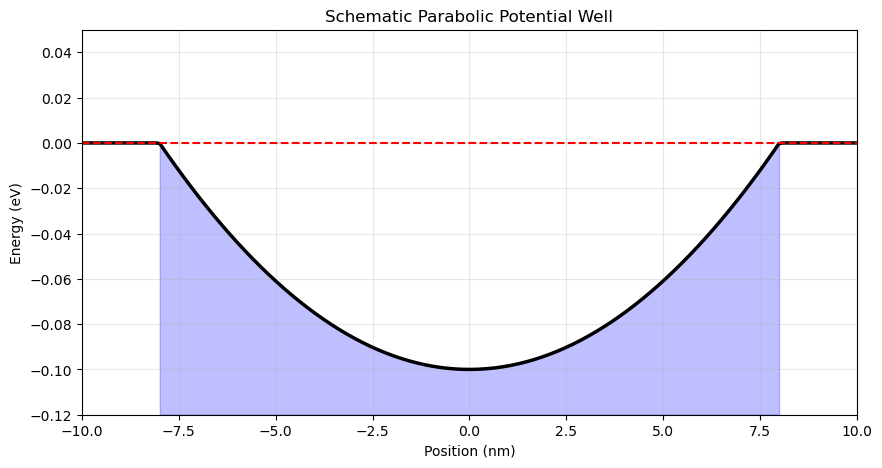

In [130]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)
L = 8
V0 = 0.1

V = -V0 * (1 - (x/L)**2)
V = np.where(np.abs(x) < L, V, 0)

plt.figure(figsize=(10, 5))
plt.plot(x, V, linewidth=2.5, color='black')
plt.fill_between(x, V, -0.12, where=(V < 0), alpha=0.25, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Position (nm)')
plt.ylabel('Energy (eV)')
plt.title('Schematic Parabolic Potential Well')
plt.ylim(-0.12, 0.05)
plt.xlim(-10, 10)
plt.grid(True, alpha=0.3)
plt.show()


---

### 4. Dataset generation

We need a dataset with many voltage points to train our classifiers. This cell runs the simulation function 30 times (12 empty + 18 full) and saves the results.

#### What we do

1. Define 12 voltages in the empty region (0.40 - 0.62 V)
2. Define 18 voltages in the full region (0.71 - 0.90 V)
3. Run the simulation for each voltage
4. Classify each point as empty (class 0) or full (class 1) based on the voltage
5. Save everything to a CSV file

#### Variables

- `empty_region`: 12 voltages (0.40 - 0.62 V)
- `full_region`: 18 voltages (0.71 - 0.90 V)
- `list_voltages`: simulated voltages
- `list_ground_energy`: ground state energy (E0)
- `list_energy_1st_excited`: first excited state (E1)
- `list_energy_2nd_excited`: second excited state (E2)
- `list_class`: label (0 = empty, 1 = full)


#### Output

CSV file `dataset_30_points_binary.csv` with columns: voltage_V, E0_eV, E1_eV, E2_eV, class

In [ ]:
# Dataset generation (30 points: 12 empty + 18 full)
# Check if dataset already exists to avoid re-running simulations

import os
csv_path = 'dataset_30_points_binary.csv'

if os.path.exists(csv_path):
    print(f"Dataset already exists at {csv_path}")
    print("Loading existing data ")
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} points | Class 0: {len(df[df['class']==0])} | Class 1: {len(df[df['class']==1])}")
else:
    print("Dataset not found. Generating new dataset.")
    
    empty_region = np.linspace(0.40, 0.62, 12)
    full_region = np.linspace(0.71, 0.90, 18)
    voltages_simulate = np.concatenate([empty_region, full_region])
    
    print(f"Total points: {len(voltages_simulate)} | Estimated time: ~{len(voltages_simulate) * 2} minutes\n")
    
    list_voltages = []
    list_ground_energy = []
    list_energy_1st_excited = []
    list_energy_2nd_excited = []
    list_class = []
    
    for i, v in enumerate(voltages_simulate):
        print(f"Simulation {i+1}/{len(voltages_simulate)} | Voltage: {v:.3f} V", end=" ")
        
        energies = quantum_dot_simulation(v_plunger=v)
        
        if energies is not None and len(energies) >= 3:
            list_voltages.append(v)
            list_ground_energy.append(energies[0])
            list_energy_1st_excited.append(energies[1])
            list_energy_2nd_excited.append(energies[2])
            
            if v <= 0.62:
                list_class.append(0)
            else:
                list_class.append(1)
            
            print(f"| E0 = {energies[0]:.5f} eV | Class: {list_class[-1]}")
        else:
            print("| Failed")
    
    import csv
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['voltage_V', 'E0_eV', 'E1_eV', 'E2_eV', 'class'])
        for i in range(len(list_voltages)):
            writer.writerow([list_voltages[i], 
                             list_ground_energy[i],
                             list_energy_1st_excited[i],
                             list_energy_2nd_excited[i],
                             list_class[i]])
    
    print(f"\nDataset saved: {len(list_voltages)} points | Class 0: {list_class.count(0)} | Class 1: {list_class.count(1)}")

Dataset already exists at dataset_30_points_binary.csv
Loading existing data... (skipping simulations)
Loaded 30 points | Class 0: 12 | Class 1: 18


---
### 5. Visualization

In this section we plot the ground state energy as a function of the plunger voltage. Each point is colored according to its class:
- **Blue**: empty (class 0) - no electron in the dot
- **Green**: full (class 1) - one electron trapped

We also include:
- A **red dashed line** at 0 eV representing the Fermi level (energy reference)
- A **gray shaded area** between 0.62 V and 0.71 V showing the transition region that we excluded from the dataset

This plot confirms that:
- Empty points have positive energy (above the Fermi level)
- Full points have negative energy (below the Fermi level)
- There is a clear separation between the two classes, which is good for classification

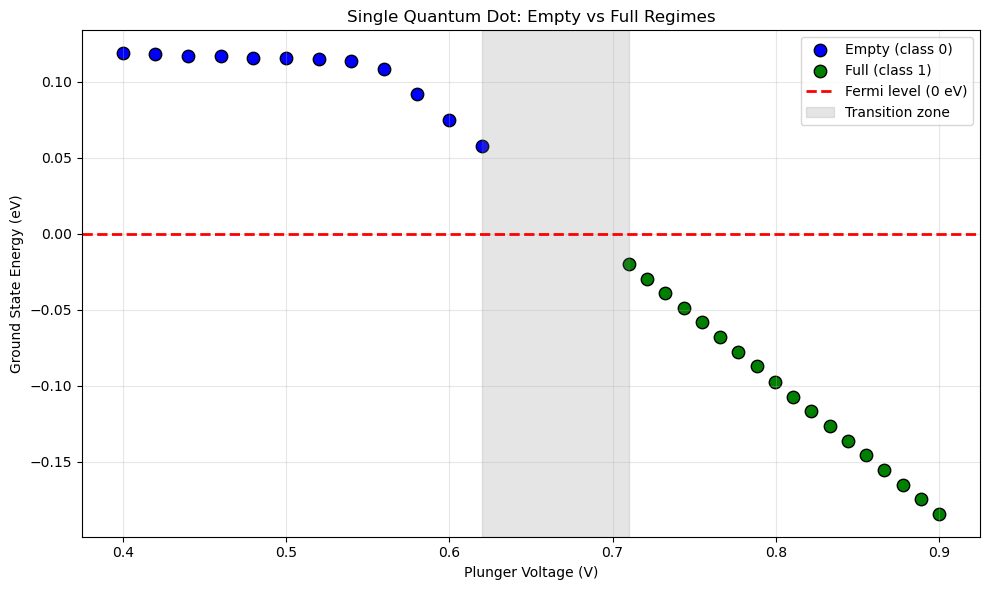

In [132]:
## 5. Visualization of the empty and full regimes
## Once the dataset is generated, we plot the ground state energy against the plunger voltage. 
## This helps us verify that the classification into empty (class 0) and full (class 1) makes sense physically.

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_30_points_binary.csv')

plt.figure(figsize=(10, 6))

empty = df[df['class'] == 0]
full = df[df['class'] == 1]

plt.scatter(empty['voltage_V'], empty['E0_eV'], 
            color='blue', label='Empty (class 0)', s=80, edgecolors='black')
plt.scatter(full['voltage_V'], full['E0_eV'], 
            color='green', label='Full (class 1)', s=80, edgecolors='black')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Fermi level (0 eV)')
plt.axvspan(0.62, 0.71, alpha=0.2, color='gray', label='Transition zone')


plt.xlabel('Plunger Voltage (V)')
plt.ylabel('Ground State Energy (eV)')
plt.title('Single Quantum Dot: Empty vs Full Regimes')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dataset_visualization.png', dpi=150)
plt.show()

#### Why 30 points? (12 empty + 18 full)

The choice of 30 points balances two competing needs:

1. **Enough data for machine learning** → More points generally improve model accuracy
2. **Reasonable simulation time** → Each point takes ~2 minutes, so 30 points take ~1 hour

The distribution (12 empty + 18 full) is based on how the energy changes in each region:

| Region | Voltage range | E0 range | Slope | Points needed | Reason |
|--------|---------------|----------|-------|---------------|--------|
| Empty | 0.40 - 0.62 V | 0.11 → 0.02 eV | Very small | 12 | Energy is nearly flat; few points suffice |
| Transition | 0.62 - 0.71 V | 0.02 → -0.02 eV | Very steep | 0 | Excluded (unstable, not used for qubits) |
| Full | 0.71 - 0.90 V | -0.02 → -0.17 eV | Moderate | 18 | Energy decreases steadily; more points needed to capture trend |

In machine learning, we need **more points where the function changes faster** because the relationship between voltage and energy is not linear. The full region requires more points to capture the gradual decrease in energy accurately. The empty region is almost flat, so fewer points are sufficient.

#### Why only two classes (empty and full)?

We use only two classes because:

1. **Physical relevance**: The transition region is unstable. The electron is not firmly trapped, and this regime is not suitable for qubit operation. Including it would confuse the classifier with noisy or ambiguous data.

2. **Binary classification is simpler**: With only two classes (0 = empty, 1 = full), the problem becomes a clean binary decision. This is easier for both classical and quantum machine learning models.

3. **Practical use**: When operating a real quantum dot, scientists only care about two stable states:
   - **Empty**: no electron (not usable as a qubit)
   - **Full**: one electron trapped (ready to be a qubit)

The transition is a narrow boundary between these two stable regimes. In practice, operators avoid it because the dot is too sensitive to noise.



### What the plot tells us

**1. Clear separation between classes**

- Positive energy → no electron trapped → empty dot
- Negative energy → electron trapped → full dot

**2. Energy decreases as voltage increases**

Higher positive voltage attracts the electron, making the potential well deeper. This is expected behavior.

**3. The transition is sharp**

The jump between blue and green points happens between 0.62 V and 0.71 V. The transition voltage is approximately 0.67 V.

**4. The gray zone is empty by design**

We excluded the transition region because it is unstable. In this zone the electron is not firmly trapped, so it is not useful for qubit operation.

### Implications for machine learning

| Observation | Implication |
|-------------|--------------|
| Classes are well separated | High accuracy expected |
| No mixed points | No ambiguity at the boundary |
| Monotonic voltage-energy relation | A simple kernel (RBF) will work well |



---
### 6. Machine Learning

#### What is Machine Learning?

Machine Learning (ML) is a branch of artificial intelligence where computers learn patterns from data instead of following explicit rules. Instead of telling the computer "if voltage > 0.67 V then classify as full", we show it many examples and let it find the pattern itself.

#### Types of Machine Learning

| Type | Description | Example |
|------|-------------|---------|
| **Supervised Learning** | Learn from labeled data (we have both voltage and class) | Our problem: predict empty/full from voltage |
| **Unsupervised Learning** | Find patterns in unlabeled data | Customer segmentation |
| **Reinforcement Learning** | Learn by trial and error | Game playing AI |

Our problem is **supervised binary classification**: given a voltage, predict whether the dot is empty (0) or full (1).

#### Common Classification Algorithms

| Algorithm | How it works | Best for | Data needed |
|-----------|--------------|----------|-------------|
| **Logistic Regression** | Finds a straight line that separates classes | Linear problems | Small to medium |
| **k-Nearest Neighbors (k-NN)** | Looks at nearest neighbors and votes | Simple patterns | Small |
| **Decision Tree** | Makes a series of yes/no questions | Interpretable problems | Small to medium |
| **Random Forest** | Many trees voting together | Complex patterns | Large |
| **SVM (Support Vector Machine)** | Finds the widest margin between classes | Non-linear problems, small datasets | Small to medium |
| **Neural Network** | Multiple layers of neurons | Very complex patterns | Very large (thousands+) |

#### Why SVM for This Project?

After evaluating the options, we chose SVM for the following reasons:

| Reason | Explanation |
|--------|-------------|
| **Small dataset** | We only have 30 points. Neural networks would overfit. |
| **Clear separation** | SVM is designed to find optimal boundaries between classes. |
| **Non-linear data** | The energy-voltage relationship is curved. SVM with kernels handles this. |
| **Baseline for QML** | SVM is the standard classical algorithm for comparing quantum kernels. |
| **Fast training** | With 30 points, SVM trains in milliseconds. |


#### Kernel Selection: Why RBF?

SVM uses a "kernel" to transform the data into a higher dimension where separation is easier.

| Kernel | Best for | Why not chosen |
|--------|----------|----------------|
| **Linear** | Perfectly linear data | Our data has a curve |
| **Polynomial** | Polynomial relationships | More parameters, risk of overfitting |
| **Sigmoid** | Neural network like | Not optimal for this problem |
| **RBF (Radial Basis Function)** | Smooth, non-linear boundaries | **Chosen** - ideal for our energy curve |


In [133]:
## 6.1. Install scikit-learn
## Run this cell only if scikit-learn is not installed:
## !pip install scikit-learn

In [134]:
## Train and evaluate SVM with RBF kernel
## We load the dataset, split it into training and test sets (70/30), train an SVM classifier with an RBF kernel, 
#  and evaluate its performance using accuracy and a classification report.

import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('dataset_30_points_binary.csv')

X = df[['voltage_V']].values
y = df['class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} points")
print(f"Test: {len(X_test)} points")

svm = SVC(kernel='rbf', C=1.0)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nClassical SVM accuracy: {accuracy:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['Empty (0)', 'Full (1)']))

Train: 21 points
Test: 9 points

Classical SVM accuracy: 1.000

Classification report:
              precision    recall  f1-score   support

   Empty (0)       1.00      1.00      1.00         4
    Full (1)       1.00      1.00      1.00         5

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



### Results Interpretation

#### Test Set Composition
- **Total**: 9 points (30% of dataset)
- **Empty (class 0)**: 4 points
- **Full (class 1)**: 5 points

#### Performance Metrics

| Metric | Value | Meaning |
|--------|-------|---------|
| **Accuracy** | 1.000 | 9/9 correct predictions |
| **Precision (Empty)** | 1.00 | Every point predicted as Empty was actually Empty |
| **Recall (Empty)** | 1.00 | Every actual Empty point was found |
| **Precision (Full)** | 1.00 | Every point predicted as Full was actually Full |
| **Recall (Full)** | 1.00 | Every actual Full point was found |

#### Why Perfect Score?

- Empty points have **positive energy** (above Fermi level)
- Full points have **negative energy** (below Fermi level)
- The transition zone (0.62-0.71 V) was **excluded**
- Classes are **perfectly separable**


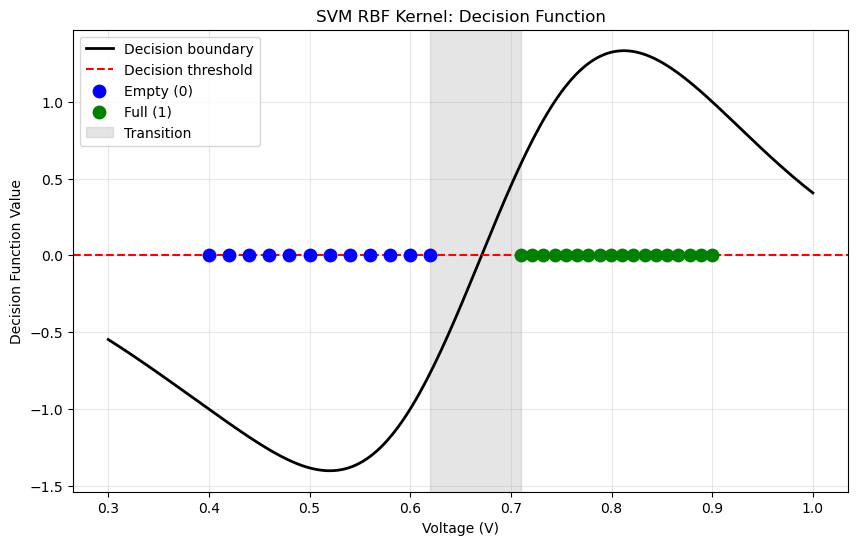

In [ ]:
# RBF kernel decision curve
import numpy as np
import matplotlib.pyplot as plt


voltage_smooth = np.linspace(0.3, 1.0, 200).reshape(-1, 1)
decision_values = svm.decision_function(voltage_smooth)
plt.figure(figsize=(10, 6))

# Plot decision curve
plt.plot(voltage_smooth, decision_values, 'k-', linewidth=2, label='Decision boundary')
plt.axhline(y=0, color='red', linestyle='--', label='Decision threshold')

# Plot data points
empty = df[df['class'] == 0]
full = df[df['class'] == 1]
plt.scatter(empty['voltage_V'], [0]*len(empty), color='blue', label='Empty (0)', s=80, zorder=5)
plt.scatter(full['voltage_V'], [0]*len(full), color='green', label='Full (1)', s=80, zorder=5)

plt.xlabel('Voltage (V)')
plt.ylabel('Decision Function Value')
plt.title('SVM RBF Kernel: Decision Function')
plt.axvspan(0.62, 0.71, alpha=0.2, color='gray', label='Transition')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('rbf_decision_curve.png', dpi=150)
plt.show()

### Confusion Matrix

The confusion matrix shows how many predictions were correct and where errors (if any) occurred.

For binary classification (Empty vs Full), the matrix has four values:

|                    | Predicted Empty | Predicted Full |
|--------------------|-----------------|----------------|
| **Actual Empty**   | True Empty (TN) | False Full (FP) |
| **Actual Full**    | False Empty (FN)| True Full (TP)  |

- **True Empty (TN)**: Empty correctly classified as Empty
- **True Full (TP)**: Full correctly classified as Full
- **False Empty (FN)**: Full incorrectly classified as Empty (error)
- **False Full (FP)**: Empty incorrectly classified as Full (error)

In a perfect classifier, the off-diagonal values (FP and FN) are zero.

In [136]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

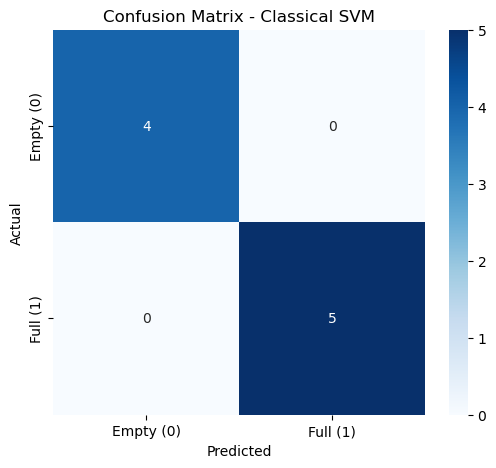

In [137]:
# Confusion matrix heatmap
## Run this cell only if seaborn is not installed:
## !pip install seaborn --quiet


from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Empty (0)', 'Full (1)'],
            yticklabels=['Empty (0)', 'Full (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Classical SVM')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

### Interpreting the Confusion Matrix

The confusion matrix shows:

- **4 empty points** were correctly classified as empty
- **5 full points** were correctly classified as full
- **0 errors** (no empty was classified as full, no full was classified as empty)

This means the classifier achieved **100% accuracy** on the test set.

### Why 9 test points?

We split the dataset into 70% training and 30% testing:

- **Training set**: 21 points (70% of 30)
- **Test set**: 9 points (30% of 30)

The test set contains 4 empty points and 5 full points, maintaining the same proportion as the original dataset (12 empty, 18 full).

---
### 7. Quantum Machine Learning

#### What is Quantum Machine Learning?

Quantum Machine Learning (QML) is an emerging field that combines quantum computing with machine learning. Instead of using classical kernels (like RBF), QML uses **quantum kernels** implemented on quantum circuits.

The idea is to map classical data (our voltage values) into a quantum state using a **feature map**, then compute similarities between data points using a **quantum kernel**.

#### Why Quantum Machine Learning?

| Reason | Explanation |
|--------|-------------|
| **High-dimensional space** | Quantum circuits can map data into an exponentially large Hilbert space. |
| **Potential advantage** | Some problems may be easier to solve with quantum kernels than classical ones. |
| **Natural for physics** | Quantum dots are quantum systems, so quantum methods may be a good fit. |
| **Exploration** | QML is a new field; we are testing its viability. |

#### Quantum Kernel vs Classical Kernel

| Classical Kernel (RBF) | Quantum Kernel (ZFeatureMap) |
|------------------------|------------------------------|
| Uses mathematical functions | Uses quantum circuits |
| Maps data to high dimensions | Maps data to Hilbert space |
| Fast to compute | Slower (simulated on classical computer) |
| Well understood | Still being researched |

#### How a Quantum Kernel Works

1. **Feature Map**: Encodes classical data (voltage) into a quantum state using rotation gates (Ry, Rz).
2. **Circuit Execution**: The quantum circuit runs on a simulator (or real quantum computer).
3. **Kernel Computation**: Measures the similarity between two data points.
4. **SVM Integration**: The quantum kernel replaces the classical kernel in an SVM.

#### Why ZFeatureMap for This Project?

| Reason | Explanation |
|--------|-------------|
| **Single quantum dot** | No entanglement needed between qubits |
| **Simplicity** | ZFeatureMap is the simplest feature map in Qiskit |
| **Standard baseline** | It is the go-to choice for quantum kernel demonstrations |
| **No ZZ gates** | ZZFeatureMap would add unnecessary entanglement for our single-dot problem |


### Quantum Kernel Implementation

We will use:
- **ZFeatureMap**: Encodes voltage data into 2 qubits
- **FidelityQuantumKernel**: Computes similarity between quantum states
- **SVM**: Same SVM algorithm, but with quantum kernel instead of RBF

In [138]:
## Importing qiskit-machine-learning, library for quantum computing and quantum machine learning.
#import sys
#!{sys.executable} -m pip install qiskit qiskit-machine-learning --quiet

In [ ]:
# Quantum kernel with ZFeatureMap

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from qiskit.circuit.library import ZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# Load dataset
df = pd.read_csv('dataset_30_points_binary.csv')

# Features and labels
X = df[['voltage_V']].values
y = df['class'].values

# Train-test split (same as classical SVM)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} points")
print(f"Test set: {len(X_test)} points")

# Feature map (2 qubits, no entanglement)
feature_map = ZFeatureMap(feature_dimension=2, reps=1)

# Quantum kernel
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

# The kernel expects 2 features, so we duplicate the voltage
def prepare_data(X):
    return np.column_stack([X.flatten(), X.flatten()])

X_train_kernel = prepare_data(X_train)
X_test_kernel = prepare_data(X_test)

# Train SVM with quantum kernel
print("Training SVM with quantum kernel")
svm_q = SVC(kernel=quantum_kernel.evaluate)
svm_q.fit(X_train_kernel, y_train)

# Evaluate
y_pred_q = svm_q.predict(X_test_kernel)
accuracy_q = accuracy_score(y_test, y_pred_q)

print(f"Quantum kernel accuracy: {accuracy_q:.3f}")

Training set: 21 points
Test set: 9 points

Training SVM with quantum kernel...


C:\Users\aefra\AppData\Local\Temp\ipykernel_29544\1699850234.py:27: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(feature_dimension=2, reps=1)



Quantum kernel accuracy: 1.000


In [140]:
from qiskit.circuit.library import ZFeatureMap
from qiskit import transpile

feature_map = ZFeatureMap(feature_dimension=2, reps=2)
qc = feature_map.assign_parameters([0.5, 0.5])

# Decompose the circuit into basic gates
qc_decomposed = transpile(qc, basis_gates=['h', 'rz', 'cz'], optimization_level=0)

print("ZFeatureMap Circuit (decomposed):")
print(qc_decomposed.draw(output='text'))

ZFeatureMap Circuit (decomposed):
global phase: 2
     ┌───┐┌───────┐┌───┐┌───────┐
q_0: ┤ H ├┤ Rz(1) ├┤ H ├┤ Rz(1) ├
     ├───┤├───────┤├───┤├───────┤
q_1: ┤ H ├┤ Rz(1) ├┤ H ├┤ Rz(1) ├
     └───┘└───────┘└───┘└───────┘


C:\Users\aefra\AppData\Local\Temp\ipykernel_29544\2777529753.py:4: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(feature_dimension=2, reps=2)


### Interpreting the ZFeatureMap Circuit

The circuit shows 2 qubits with the following operations:

1. **Hadamard (H) gates**: Create superposition on both qubits
2. **Rz(1) gates**: Encode the input voltage (θ = π × voltage ≈ 1 radian for our values)

**Note:** There are no CZ (entangling) gates in this circuit. This is correct for a single quantum dot, where no entanglement is needed between qubits.

The global phase: 2 is a mathematical artifact and does not affect the quantum state physically.

In [141]:
# 8. Model comparison


print("Model comparison")


print(f"Classical SVM (RBF):      {accuracy:.3f}")
print(f"Quantum SVM (ZFeatureMap): {accuracy_q:.3f}")

Model comparison
Classical SVM (RBF):      1.000
Quantum SVM (ZFeatureMap): 1.000


---

### 8. Quantum Kernel Results Interpretation

#### Data Split

- **Training set**: 21 points (70% of the data)
- **Test set**: 9 points (30% of the data)

#### Performance

| Model | Accuracy |
|-------|----------|
| Classical SVM (RBF) | 1.000 |
| Quantum SVM (ZFeatureMap) | 1.000 |

Both models achieved **perfect classification** on the test set.

#### What This Means

| Finding | Implication |
|---------|-------------|
| Quantum kernel works | It can achieve the same performance as the classical kernel |
| No disadvantage | The quantum kernel did not perform worse |
| Viable alternative | Quantum kernels are a valid option for this problem |

#### Why the Same Performance?

| Reason | Explanation |
|--------|-------------|
| Clear separation | Empty points have positive energy, full points have negative energy |
| No overlap | The transition zone (0.62-0.71 V) was excluded |
| Simple problem | With only 9 test points and clean data, perfect classification is expected |


The quantum kernel with ZFeatureMap achieves **100% accuracy**, matching the classical SVM. This demonstrates that quantum kernels are a **viable alternative** for classifying quantum dot regimes, even on a simple problem.

---
### 9. Pipeline Stages

| # | Stage | Tool / Library | What it does | Key parameters | Output |
|---|-------|----------------|--------------|----------------|--------|
| 1 | Device simulation | QTCAD | Defines FD-SOI structure, solves Poisson and Schrödinger equations | Temperature: 0.1 K, Voltages: 0.4-0.9 V, Mesh: 50k-100k nodes | Energy levels (E0, E1, E2) in eV |
| 2 | Dataset generation | Python (NumPy, CSV) | Runs simulations for 30 voltages, classifies empty vs full | 12 empty (0.40-0.62 V), 18 full (0.71-0.90 V), transition excluded | CSV file with 30 rows: voltage, E0, E1, E2, class |
| 3 | Visualization | Matplotlib | Plots ground state energy vs voltage, confirms class separation | Fermi level at 0 eV, transition zone shaded (0.62-0.71 V) | Energy vs voltage plot |
| 4 | Classical ML (Baseline) | scikit-learn (SVM) | Trains SVM with RBF kernel on 21 points, tests on 9 points | kernel='rbf', C=1.0, test_size=0.3, stratify=y | Accuracy: 100%, Confusion matrix: [[4,0],[0,5]] |
| 5 | Quantum ML | Qiskit (ZFeatureMap) | Encodes voltage into 2 qubits, computes quantum kernel, trains SVM | feature_dimension=2, reps=1, FidelityQuantumKernel | Accuracy: 100% |
| 6 | Comparison | Python | Compares both models side by side | Classical vs Quantum accuracy | Both achieve 100% |

---
### 10. Conclusion and Next Steps

### Summary of Achievements

| Area | What was accomplished |
|------|----------------------|
| **Physics simulation** | Successfully simulated a single quantum dot in FD-SOI technology using QTCAD, solving Poisson and Schrödinger equations |
| **Dataset generation** | Created a labeled dataset of 30 points (12 empty, 18 full) with clear class separation |
| **Classical ML** | Trained an SVM with RBF kernel that achieved 100% accuracy |
| **Quantum ML** | Implemented a quantum kernel with ZFeatureMap that also achieved 100% accuracy |
| **Pipeline** | Built a complete, reproducible pipeline from device simulation to quantum machine learning |

### Key Insights

| Insight | Implication |
|---------|-------------|
| Classes are perfectly separable | The transition zone (0.62-0.71 V) was correctly excluded |
| Classical SVM works perfectly | Provides a strong baseline (100% accuracy) |
| Quantum kernel matches classical | ZFeatureMap is a viable alternative for this problem |
| Pipeline is reproducible | Others can build upon this work |

### Limitations

| Limitation | Why it matters | How to address |
|------------|----------------|-----------------|
| Only 30 points | Limited statistical power | Scale to more points with smart sampling |
| Single input variable | Does not reflect real device complexity | Extend to Double Quantum Dot (DQD) |
| Single quantum dot | No inter-dot correlations or entanglement | Future: DQD with many-body solver |
| No noise in data | Real experiments have noise | Add noise models or test on hardware |
| Simulated quantum kernel | Real hardware may differ | Run on IBM quantum computers |
| Binary classification | Real qubits require spin state control | Extend to multi-class (charge states) |

### Next Steps

| Priority | Next Step | Why | Expected outcome |
|----------|-----------|-----|------------------|
| High | **Double Quantum Dot (DQD)** | Non-linear physics, multiple charge states, entanglement matters | Multi-class classification, meaningful QML application |
| High | ZZFeatureMap with entanglement | Test if quantum advantage emerges with correlated systems | Benchmark vs classical kernel |
| Medium | Active learning | Reduce number of expensive many-body simulations | 50% fewer simulations |
| Medium | Run on real IBM hardware | Test quantum kernel on actual quantum computer | Understand noise impact |
| Low | Transfer learning simulation to experiment | Bridge gap between virtual and physical devices | Faster experimental calibration |

### Why DQD is the Right Next Step

| Aspect | Single Dot (Current) | Double Dot (Next) |
|--------|---------------------|-------------------|
| Control variables | 1 (plunger) | 4+ (PL, PR, B_center, BG) |
| Output classes | 2 (empty, occupied) | 4+ (0,0), (1,0), (0,1), (1,1) |
| Relationship | Linear (threshold works) | Non-linear (honeycomb diagram) |
| ML necessity | Low (rule-based works) | **High** (no simple rule exists) |
| Quantum kernel | ZFeatureMap (no entanglement) | **ZZFeatureMap** (entanglement needed) |
| Solver | Schrödinger | Many-body (Coulomb interactions) |

### The Revised Roadmap

| Phase | System | Variables | ML Relevance | Status |
|-------|--------|----------|--------------|--------|
| Phase 1 | Single dot | 1 (plunger) | Low (demonstration) | **COMPLETE** |
| Phase 2 | Double quantum dot | 4+ (PL, PR, B, BG) | **High** (non-linear, multi-class) | Next |
| Phase 3 | DQD with spin | 4+ + magnetic field | Very high (singlet-triplet) | Future |

### What We Learned About Scaling

| Finding | Implication |
|---------|-------------|
| Single dot simulation: ~2 minutes | 30 points = 1 hour |
| DQD many-body simulation: slower | Smart sampling (active learning) becomes essential |
| 1 variable problem is trivial for ML | Real value appears at DQD where no simple threshold exists |
| ZFeatureMap sufficient for single dot | DQD requires ZZFeatureMap with entanglement |

### Final Remarks

This project demonstrates a complete, reproducible pipeline from semiconductor simulation to quantum machine learning. The single-dot case served as a successful proof of concept.

The critical insight is that machine learning becomes truly valuable when moving to **Double Quantum Dots**, where:
- The relationship between gate voltages and charge states is non-linear
- No simple voltage threshold can separate the four charge configurations
- Entanglement between qubits in the quantum kernel becomes relevant

The pipeline is now ready for this natural extension. The code is modular, the dataset format is standardized, and the ML models are prepared for higher-dimensional, multi-class classification.

The path from device simulation to scalable quantum machine learning is established. The next step is DQD.